# Loading Real Data PSDs

In [1]:
# Import Python utilities for file directory stuff
import os
from pathlib import Path

# Import numpy for loading files
import numpy as np

## Path & File Settings

In [4]:
# Set a path object for the location of the data
data_dir = Path('/Users/chloe/DissertationSimulations/EEG data')

In [5]:
# Get a list of avaialble files in the directory
file_list = os.listdir(data_dir)

In [6]:
# Drop any hidden files that might be listed
file_list = [cfile for cfile in file_list if cfile[0] != '.']

In [7]:
# Filter file list to status of interest
status = 'ec'
file_list = [cfile for cfile in file_list if status in cfile]

In [8]:
# Print some example file names of current file list
file_list[0:3]

['A00051826_ec_psds.npz', 'A00051886_ec_psds.npz', 'A00051955_ec_psds.npz']

## Load Data File

In [9]:
# Load example data file
loaded_data = np.load(data_dir / file_list[0])

In [10]:
# Unpack loaded arrays
freqs = loaded_data['arr_0']
powers = loaded_data['arr_1']
electrodes = loaded_data['arr_2']

In [11]:
# Check freqs array
freqs

array([ 2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,
        7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. , 12.5,
       13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5, 17. , 17.5, 18. ,
       18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5, 22. , 22.5, 23. , 23.5,
       24. , 24.5, 25. , 25.5, 26. , 26.5, 27. , 27.5, 28. , 28.5, 29. ,
       29.5, 30. , 30.5, 31. , 31.5, 32. , 32.5, 33. , 33.5, 34. , 34.5,
       35. , 35.5, 36. , 36.5, 37. , 37.5, 38. , 38.5, 39. , 39.5, 40. ])

In [12]:
# Check powers array shape - this should be [n_blocks, n_electrodes, n_freqs]
powers.shape

(5, 111, 77)

In [13]:
# Check channel labels
electrodes

array(['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11',
       'E12', 'E13', 'E14', 'E15', 'E16', 'E18', 'E19', 'E20', 'E21',
       'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30',
       'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39',
       'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E50',
       'E51', 'E52', 'E53', 'E54', 'E55', 'E57', 'E58', 'E59', 'E60',
       'E61', 'E62', 'E64', 'E65', 'E66', 'E67', 'E69', 'E70', 'E71',
       'E72', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E82',
       'E83', 'E84', 'E85', 'E86', 'E87', 'E89', 'E90', 'E91', 'E92',
       'E93', 'E95', 'E96', 'E97', 'E98', 'E100', 'E101', 'E102', 'E103',
       'E104', 'E105', 'E106', 'E108', 'E109', 'E110', 'E111', 'E112',
       'E114', 'E115', 'E116', 'E117', 'E118', 'E120', 'E121', 'E122',
       'E123', 'E124', 'Cz'], dtype='<U4')

In [14]:
# Get the channel index of a desired electrode label (currently: random pick)
e_label = 'E76'
e_ind = np.where(electrodes == e_label)[0][0]

## Check example SpectralModel

In [15]:
from specparam import SpectralModel

In [16]:
fm = SpectralModel()


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 0.50 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

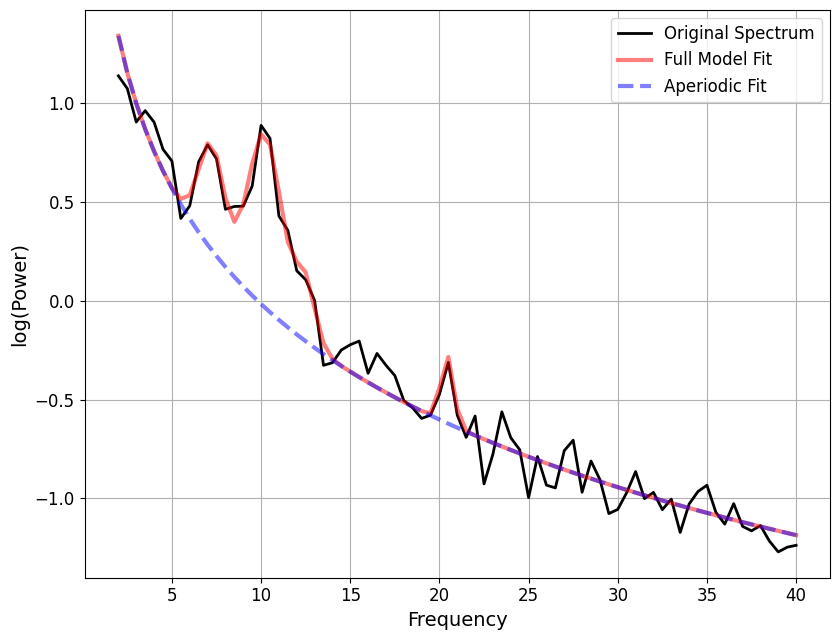

In [17]:
fm.report(freqs, powers[0, e_ind, :])

## Check Montage from MNE

In [7]:
import mne

In [8]:
hydrocel_montage = mne.channels.make_standard_montage("GSN-HydroCel-129")

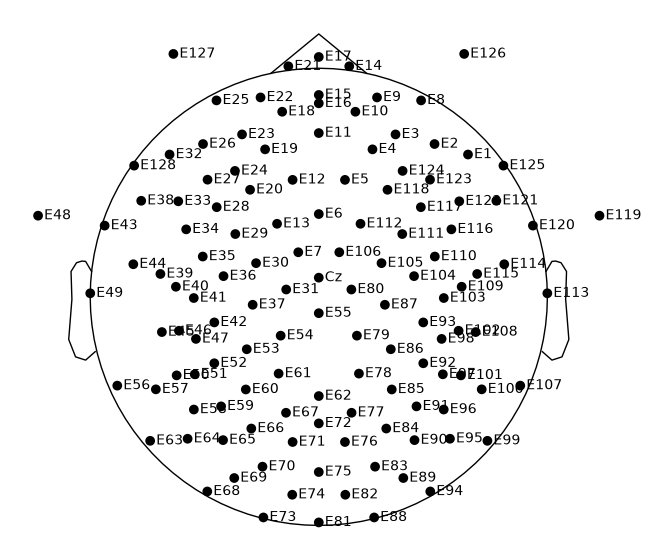

In [9]:
hydrocel_montage.plot();